In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data.csv")

df.head()



,text,source,prompt_id,text_length,word_count
0,"Federal law supersedes state law, and cannabis...",Bloom-7B,0,967,157
1,Miles feels restless after working all day. He...,Bloom-7B,0,5068,778
2,So first of I am danish. That means that I fol...,Bloom-7B,0,1602,267
3,In this paper we present a novel rule-based ap...,Bloom-7B,0,5469,848
4,"Most social progressives, love democracy, and ...",Bloom-7B,0,2379,380


In [17]:
df.describe()

,prompt_id,text_length,word_count
count,788922.000000,788922.000000,788922.000000
mean,420.069514,3123.374844,497.983404
std,1381.285340,4963.074433,720.866585
min,0.000000,105.000000,25.000000
25%,0.000000,647.000000,110.000000
50%,0.000000,1921.000000,324.000000
75%,0.000000,3910.000000,624.000000
max,9913.000000,890119.000000,71543.000000


In [18]:
df['source_binary'] = df['source'].apply(
    lambda x: 'HUMAN' if x.lower() == 'human' else 'AI'
)
df.head()

,text,source,prompt_id,text_length,word_count,source_binary
0,"Federal law supersedes state law, and cannabis...",Bloom-7B,0,967,157,AI
1,Miles feels restless after working all day. He...,Bloom-7B,0,5068,778,AI
2,So first of I am danish. That means that I fol...,Bloom-7B,0,1602,267,AI
3,In this paper we present a novel rule-based ap...,Bloom-7B,0,5469,848,AI
4,"Most social progressives, love democracy, and ...",Bloom-7B,0,2379,380,AI


In [19]:
#removing duplicates and missing values  any
df = df.dropna(subset=['text', 'source_binary'])
df = df.drop_duplicates(subset=['text'])

import re

def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r'[\r\n\t]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text'] = df['text'].apply(normalize_text)

df = df[df['word_count'] >= 10].copy()

In [21]:
def clean_for_tfidf(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_for_tfidf)
#df.to_csv("final.csv", index=False)

In [22]:
print(df.shape)
print(df['source_binary'].value_counts())
print(df[['text', 'clean_text', 'word_count','text_length']].head())

(788922, 7)
source_binary
AI       441230
HUMAN    347692
Name: count, dtype: int64
                                                text  \
0  federal law supersedes state law, and cannabis...   
1  miles feels restless after working all day. he...   
2  so first of i am danish. that means that i fol...   
3  in this paper we present a novel rule-based ap...   
4  most social progressives, love democracy, and ...   

                                          clean_text  word_count  text_length  
0  federal law supersedes state law and cannabis ...         157          967  
1  miles feels restless after working all day he ...         778         5068  
2  so first of i am danish that means that i foll...         267         1602  
3  in this paper we present a novel rule based ap...         848         5469  
4  most social progressives love democracy and so...         380         2379  


source_binary
AI       2058.903477
HUMAN    4474.216111
Name: text_length, dtype: float64


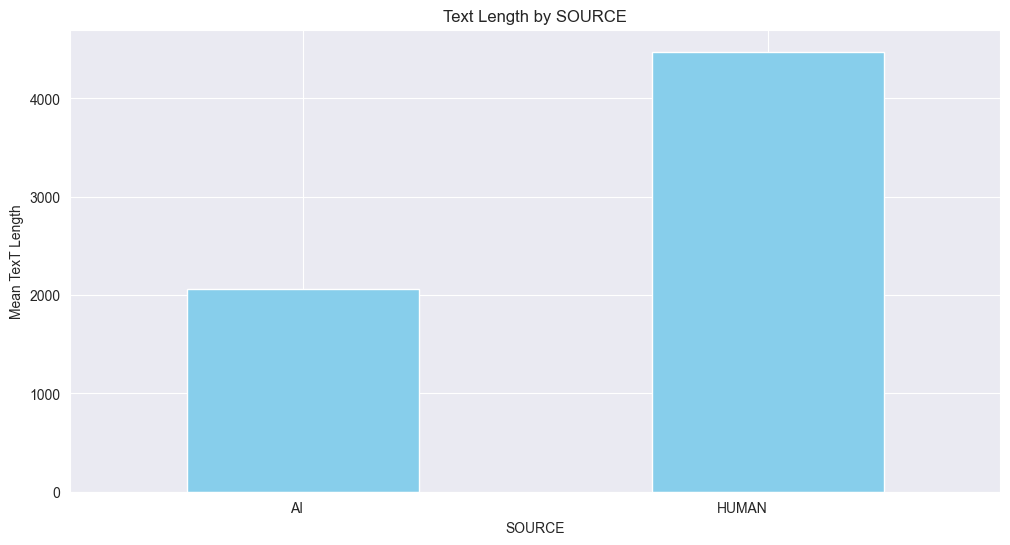

In [23]:
mean_prices_by_sublocality = df.groupby('source_binary')['text_length'].mean().sort_values()
print(mean_prices_by_sublocality)
# Bar plot for mean prices by LOCALITY
plt.figure(figsize=(12, 6))
mean_prices_by_sublocality.plot(kind='bar', color='skyblue')
plt.title('Text Length by SOURCE')
plt.xlabel('SOURCE')
plt.ylabel('Mean TexT Length')

plt.xticks(rotation=0, ha='right') # Rotate x-axis labels for better readability
plt.show()

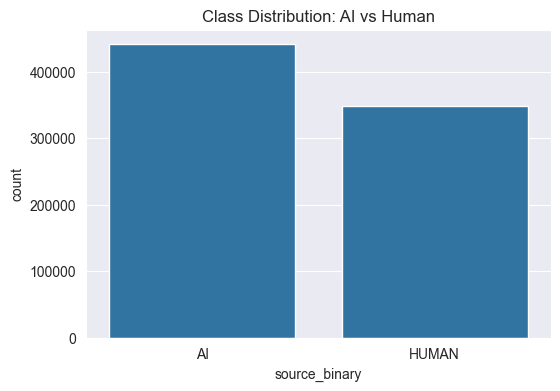

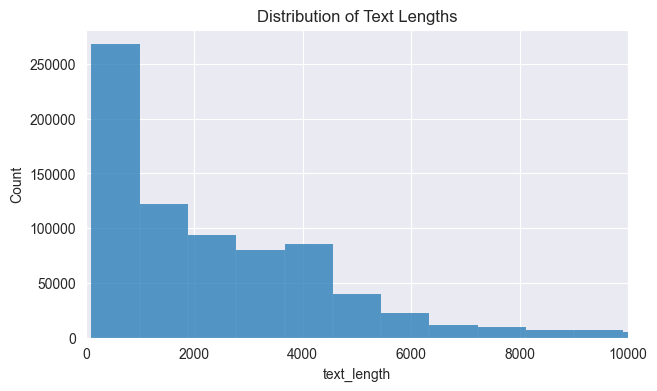

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="source_binary")
plt.title("Class Distribution: AI vs Human")
plt.show()

# TITLE LENGTH DISTRIBUTION
plt.figure(figsize=(7,4))
sns.histplot(df["text_length"], bins=1000)
plt.title("Distribution of Text Lengths")
plt.xlim(0, 10000)
plt.show() #we can see that most title length are in the 8-15 range

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
#df = df.sample(500000, random_state=42).reset_index(drop=True)
tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(df['clean_text'])

In [26]:
import re
#sentence count
df['sentence_count'] = df['text'].apply(
    lambda x: len(re.findall(r'[.!?]+', x))
)

In [27]:
import textstat

df['flesch'] = df['text'].apply(textstat.flesch_reading_ease)

In [28]:
import string

def punct_density(text):
    punct = sum(1 for c in text if c in string.punctuation)
    words = len(text.split())
    return punct / (words + 1)

df['punct_density'] = df['text'].apply(punct_density)

df.to_csv("C:\\Users\\17aya\\Downloads\\dataset\\final1.csv", index=False)

                word_count  sentence_count  text_length    flesch  \
word_count        1.000000        0.933079     0.967080 -0.206880   
sentence_count    0.933079        1.000000     0.916090 -0.104768   
text_length       0.967080        0.916090     1.000000 -0.229299   
flesch           -0.206880       -0.104768    -0.229299  1.000000   
punct_density     0.004171        0.066028     0.007924  0.091292   

                punct_density  
word_count           0.004171  
sentence_count       0.066028  
text_length          0.007924  
flesch               0.091292  
punct_density        1.000000  


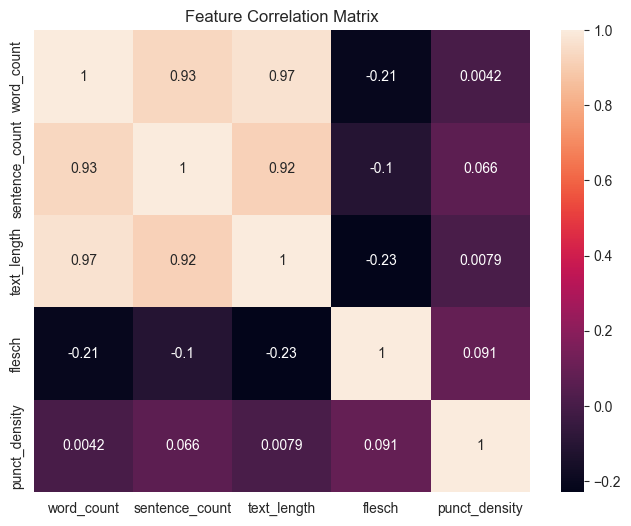

In [91]:
corr = df[['word_count', 'sentence_count', 'text_length',
           'flesch', 'punct_density']].corr()

print(corr)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.title("Feature Correlation Matrix")
plt.show()

In [90]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select features
features = df[['word_count', 'sentence_count', 'text_length',
               'flesch', 'punct_density']].copy()

# Add constant (required for VIF)
features['intercept'] = 1

# Compute VIF
vif_data = pd.DataFrame()
vif_data['Feature'] = features.columns

vif_data['VIF'] = [
    variance_inflation_factor(features.values, i)
    for i in range(features.shape[1])
]

print(vif_data)

          Feature        VIF
0      word_count  19.904604
1  sentence_count   8.750498
2     text_length  16.223896
3          flesch   1.148035
4   punct_density   1.033729
5       intercept   8.177141


In [29]:
df.to_csv("final1.csv", index=False)

In [30]:
extra_features = df[
    ['word_count', 'sentence_count', 'text_length',
     'flesch', 'punct_density'] #'noun_ratio', 'verb_ratio', 'adj_ratio']
].values

In [62]:
#!python -m spacy download en_core_web_sm
#!pip install scikit-learn opencv-python tqdm -q
import spacy
from tqdm.auto import tqdm

# 1. Register tqdm with pandas
tqdm.pandas()
nlp = spacy.load("en_core_web_sm")
# Samples 100 rows from each label (0 and 1)
df_s = df.groupby('source_binary').sample(n=40000, random_state=42)

def pos_ratios(text):
    doc = nlp(text)
    total = len(doc)

    noun = sum(1 for token in doc if token.pos_ == 'NOUN')
    verb = sum(1 for token in doc if token.pos_ == 'VERB')
    adj  = sum(1 for token in doc if token.pos_ == 'ADJ')

    return noun/total, verb/total, adj/total

df_s[['noun_ratio', 'verb_ratio', 'adj_ratio']] = df_s['text'].progress_apply(
    lambda x: pd.Series(pos_ratios(x))
)
df.to_csv("final_pos.csv", index=False)

100%|██████████| 80000/80000 [2:32:26<00:00,  8.75it/s]   


In [37]:
from sklearn.model_selection import train_test_split

df['source_binary'] = df['source_binary'].apply(lambda x: 0 if x == 'HUMAN' else 1)
y = df['source_binary']

X_tfidf_train, X_tfidf_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_tfidf,
    y,
    df.index,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [31]:
from xgboost import XGBClassifier

def modelTrain(X_train, y_train):

    model = XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
)

    model.fit(X_train, y_train)
    modelPredict(X_test, y_test, model)

In [82]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def modelPredict(X_test, y_test,model):
    # y_pred = model.predict(X_test)
    # y_prob = model.predict_proba(X_test)[:, 1]

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_test_prob = model.predict_proba(X_test)[:, 1]

    from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

    print("TRAIN PERFORMANCE")
    print("Accuracy:", accuracy_score(y_train, y_train_pred))
    print("F1:", f1_score(y_train, y_train_pred))
    print("ROC-AUC:", roc_auc_score(y_train, y_train_prob))

    print("\nTEST PERFORMANCE")
    print("Accuracy:", accuracy_score(y_test, y_test_pred))
    print("F1:", f1_score(y_test, y_test_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_test_prob))

    # print("Accuracy:", accuracy_score(y_test, y_pred))
    # print("Precision:", precision_score(y_test, y_pred))
    # print("Recall:", recall_score(y_test, y_pred))
    # print("F1-score:", f1_score(y_test, y_pred))
    # print("ROC-AUC:", roc_auc_score(y_test, y_prob))

In [32]:
######### MODEL 1 - ONLY TFIDF #################
X_train = X_tfidf_train
X_test = X_tfidf_test

modelTrain(X_train, y_train)


C:\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:14:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.8457141046360553
Precision: 0.8121922144923005
Recall: 0.941946377172903
F1-score: 0.8722703184847054
ROC-AUC: 0.934221498029089


In [51]:
############# Model 2 - Text Statistics features #####################
from sklearn.model_selection import train_test_split

X=df[['word_count', 'sentence_count', 'text_length']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


modelTrain(X_train, y_train)


(788922, 10)
(788922, 3)
(788922,)


C:\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:13:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.7367430364103051
Precision: 0.7314048354880702
Recall: 0.8353327053375855
F1-score: 0.7799217980099818
ROC-AUC: 0.8258605443109666


In [54]:
############# Model 3 - Text Statistics + readability features #####################

X=df[['word_count', 'sentence_count', 'text_length','flesch','punct_density']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


modelTrain(X_train, y_train)

C:\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:14:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.7508888677630954
Precision: 0.7485713703639568
Recall: 0.8340388827728661
F1-score: 0.7889973266338133
ROC-AUC: 0.8404420781050064


In [55]:
############# Model 4 - Text Statistics + TFIDF features #####################

import scipy.sparse as sp
X_numeric = df[['word_count', 'sentence_count', 'text_length']].values

# Stack them horizontally: TF-IDF features + 3 metadata features
X_combined = sp.hstack([X_tfidf, X_numeric])
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)


modelTrain(X_train, y_train)

C:\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:17:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.8626675539499953
Precision: 0.8447735480924904
Recall: 0.9238233591719536
F1-score: 0.882531834962351
ROC-AUC: 0.947210967499061


In [56]:
############# Model 5 - Text Statistics + readability + tfidf features #####################

import scipy.sparse as sp
X_numeric = df[['word_count', 'sentence_count', 'text_length','flesch']].values

# Stack them horizontally: TF-IDF features + 3 metadata features
X_combined = sp.hstack([X_tfidf, X_numeric])
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)


modelTrain(X_train, y_train)

C:\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:27:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.8650632189371613
Precision: 0.8455515793393046
Recall: 0.9278410187150299
F1-score: 0.8847870906995243
ROC-AUC: 0.9483724598899044


In [77]:
############# Model 6 - Text Statistics + readability + PUNCTUATION + TFIDF features #####################

import scipy.sparse as sp
X_numeric = df[['word_count', 'sentence_count', 'text_length','flesch','punct_density']].values
y=df['source_binary']
# Stack them horizontally: TF-IDF features + 3 metadata features
X_combined = sp.hstack([X_tfidf, X_numeric])
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42)


modelTrain(X_train, y_train)

C:\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:03:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.8650758944132839
Precision: 0.8472355019746415
Recall: 0.9252079763026183
F1-score: 0.8845066754913715
ROC-AUC: 0.9479553149332467


In [74]:
##################### MODEL 7 - ALL FEATURES COMBINED WITH POS TAGGING ################
import scipy.sparse as sp
X_numeric = df_s[['word_count', 'sentence_count', 'text_length','flesch','punct_density','noun_ratio', 'verb_ratio', 'adj_ratio']].values
y= df_s['source_binary']
# Stack them horizontally: TF-IDF features + 3 metadata features
#X_combined = sp.hstack([X_tfidf, X_numeric])
X_train, X_test, y_train, y_test = train_test_split(X_numeric, y, test_size=0.2, random_state=42)


modelTrain(X_train, y_train)

C:\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:28:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.7655625
Precision: 0.7688916876574308
Recall: 0.7611270415160204
F1-score: 0.7649896623018608
ROC-AUC: 0.8580796314549604


In [75]:
##################### MODEL 8 -  WITH POS TAGGING ################
import scipy.sparse as sp
X_numeric = df_s[['noun_ratio', 'verb_ratio', 'adj_ratio']].values
y= df_s['source_binary']
# Stack them horizontally: TF-IDF features + 3 metadata features
#X_combined = sp.hstack([X_tfidf, X_numeric])
X_train, X_test, y_train, y_test = train_test_split(X_numeric, y, test_size=0.2, random_state=42)


modelTrain(X_train, y_train)

C:\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:33:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.6498125
Precision: 0.6690436241610739
Recall: 0.5965590325395836
F1-score: 0.6307256310551638
ROC-AUC: 0.7027535299110421
